In [1]:
import pandas as pd
import json
import ast

In [2]:
# Load the JSON file
try:
    with open('final_flickr_mergedGT_test.json', 'r') as f:
        data = json.load(f)

    # Check if the data has an 'images' key and it's a list
    if 'images' in data and isinstance(data['images'], list):
        images_data = data['images']
        annotations_data = data['annotations']

        # Normalize the 'images' data
        # This will flatten nested structures and handle varying list lengths
        df_images = pd.json_normalize(images_data)
        df_annotations = pd.json_normalize(annotations_data)

        print("JSON file loaded and normalized successfully.")
        display(df_images.head())
        display(df_annotations.head())
    else:
        print("Error: The JSON structure does not contain a list under the key 'images'.")

except FileNotFoundError:
    print("Error: final_flickr_mergedGT_test.json not found. Please make sure the file is in the correct directory.")
except Exception as e:
    print(f"An error occurred: {e}")

JSON file loaded and normalized successfully.


,file_name,height,width,id,caption,dataset_name,tokens_negative,sentence_id,original_img_id,tokens_positive_eval
0,1016887272.jpg,500,333,153901,Several climbers in a row are climbing the roc...,flickr,"[[0, 97]]",0,1016887272,"[[[0, 16]], [[39, 47]], [[54, 61]], [[65, 68]]..."
1,1016887272.jpg,500,333,153902,Seven climbers are ascending a rock face whils...,flickr,"[[0, 85]]",1,1016887272,"[[[0, 14]], [[29, 40]], [[48, 59]], [[75, 83]]]"
2,1016887272.jpg,500,333,153903,A group of people are rock climbing on a rock ...,flickr,"[[0, 61]]",2,1016887272,"[[[0, 17]], [[39, 59]]]"
3,1016887272.jpg,500,333,153904,A group of people climbing a rock while one ma...,flickr,"[[0, 54]]",3,1016887272,"[[[0, 17]], [[27, 33]], [[40, 47]]]"
4,1016887272.jpg,500,333,153905,A collage of one person climbing a cliff .,flickr,"[[0, 42]]",4,1016887272,"[[[0, 23]], [[33, 40]]]"


,area,iscrowd,image_id,category_id,id,bbox,tokens_positive,phrase_ids
0,21186.0,0,153901,1,430844,"[74.0, 302.0, 107.0, 198.0]","[[54, 61]]",3
1,148072.0,0,153901,1,430845,"[1.0, 54.0, 332.0, 446.0]","[[39, 47]]",2
2,28083.0,0,153901,1,430846,"[119.0, 81.0, 69.0, 407.0]","[[87, 95]]",5
3,7236.0,0,153901,1,430847,"[75.0, 327.0, 67.0, 108.0]","[[65, 68]]",4
4,33088.0,0,153901,1,430848,"[162.0, 102.0, 94.0, 352.0]","[[0, 16]]",0


In [3]:
def extract_positive_spans(row):
    caption = row['caption']
    tokens_positive_eval = row['tokens_positive_eval']
    if isinstance(tokens_positive_eval, list):
        positive_spans = [caption[start:end] for group in tokens_positive_eval for start, end in group]
        return positive_spans
    else:
        return [] # Return an empty list or other appropriate value if tokens_positive_eval is not a list

df_images['positive_spans'] = df_images.apply(extract_positive_spans, axis=1)

print("New column 'positive_spans' created successfully.")
display(df_images[['caption', 'tokens_positive_eval', 'positive_spans']].head())

New column 'positive_spans' created successfully.


,caption,tokens_positive_eval,positive_spans
0,Several climbers in a row are climbing the roc...,"[[[0, 16]], [[39, 47]], [[54, 61]], [[65, 68]]...","[Several climbers, the rock, the man, red, the..."
1,Seven climbers are ascending a rock face whils...,"[[[0, 14]], [[29, 40]], [[48, 59]], [[75, 83]]]","[Seven climbers, a rock face, another man, the..."
2,A group of people are rock climbing on a rock ...,"[[[0, 17]], [[39, 59]]]","[A group of people, a rock climbing wall]"
3,A group of people climbing a rock while one ma...,"[[[0, 17]], [[27, 33]], [[40, 47]]]","[A group of people, a rock, one man]"
4,A collage of one person climbing a cliff .,"[[[0, 23]], [[33, 40]]]","[A collage of one person, a cliff]"


In [4]:
# Calculate the number of positive spans for each row
df_images['objects_num'] = df_images['positive_spans'].apply(len)

# Get the distribution of object counts
distribution = df_images['objects_num'].value_counts().sort_index()

# Convert to DataFrame for cumulative calculation
dist_df = distribution.reset_index()
dist_df.columns = ['objects_num', 'count']
dist_df = dist_df.sort_values('objects_num')

# Compute cumulative sum and cumulative percentage
dist_df['cumulative'] = dist_df['count'].cumsum()
total = dist_df['count'].sum()
dist_df['cumulative_percent'] = dist_df['cumulative'] / total * 100

# Determine cutoff where cumulative percent reaches > 95%
# Find the first row where cumulative_percent is greater than 95%
cutoff_row = dist_df[dist_df['cumulative_percent'] > 95].iloc[0]
cutoff_value = cutoff_row['objects_num']

print(f"\nCutoff where cumulative percent exceeds 95%: {cutoff_value} objects")

# Optional: display the full distribution table with cumulative info
from IPython.display import display
display(dist_df)


Cutoff where cumulative percent exceeds 95%: 5.0 objects


,objects_num,count,cumulative,cumulative_percent
0,1,490,490,9.861139
1,2,1585,2075,41.758905
2,3,1579,3654,73.535923
3,4,838,4492,90.400483
4,5,281,4773,96.055544
5,6,117,4890,98.410143
6,7,41,4931,99.235259
7,8,25,4956,99.738378
8,9,5,4961,99.839002
9,10,4,4965,99.919501


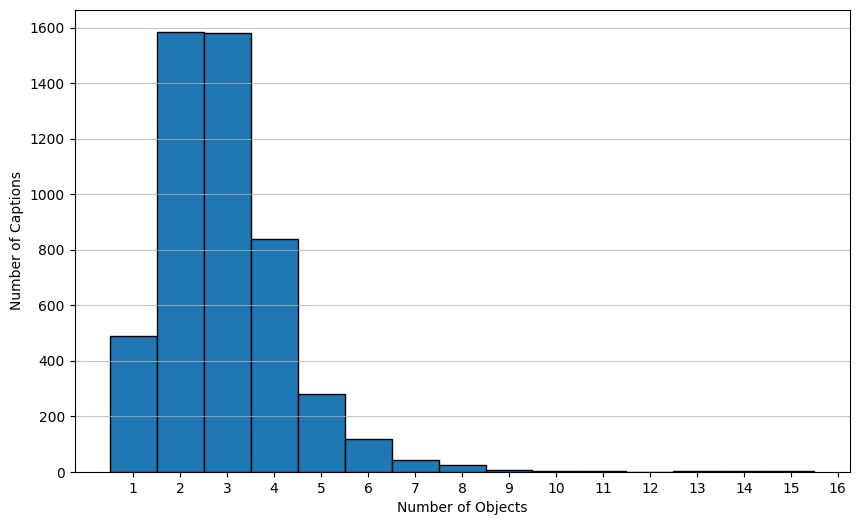

In [5]:
import matplotlib.pyplot as plt

# Plot the histogram
plt.figure(figsize=(10, 6))
counts, bin_edges, patches = plt.hist(df_images['objects_num'], bins=range(1, df_images['objects_num'].max() + 2), align='left', edgecolor='black')
plt.xlabel('Number of Objects')
plt.ylabel('Number of Captions')
plt.xticks(bin_edges) # Set xticks to be the bin edges
plt.grid(axis='y', alpha=0.75)
plt.show()

In [7]:
# Only convert tokens_positive if it's stored as string
if isinstance(df_annotations['tokens_positive'].iloc[0], str):
    df_annotations['tokens_positive'] = df_annotations['tokens_positive'].apply(ast.literal_eval)

# Find local prompt based on the tokens and the caption
def findLocalPrompt(tokens, caption):
    local_prompt = [caption[start:end] for start, end in tokens]
    return local_prompt[0]

def xywh_to_xyxy(box):
    x, y, w, h = box
    return [x, y, x + w, y + h]

def rescale_box_xyxy(box, orig_w, orig_h, target_size=512):
    x1, y1, x2, y2 = box
    x_scale = target_size / orig_w
    y_scale = target_size / orig_h
    return [
        int(x1 * x_scale),
        int(y1 * y_scale),
        int(x2 * x_scale),
        int(y2 * y_scale)
    ]

image_boxes = {}

# Iterate over each image
for _, img_row in df_images.iterrows():
    img_id = img_row['id']
    caption = img_row['caption']
    eval_tokens = img_row['tokens_positive_eval']
    orig_w = int(img_row['width'])
    orig_h = int(img_row['height'])
    boxes = []

    # Filter annotations for the current image
    matching_annots = df_annotations[df_annotations['image_id'] == img_id]

    for _, ann_row in matching_annots.iterrows():
        if ann_row['tokens_positive'] in eval_tokens:
            # extract local prompt from the captions using the tokens
            obj = findLocalPrompt(ann_row['tokens_positive'], caption)
            # convert bbox format
            xyxy_box = xywh_to_xyxy(ann_row['bbox'])
            # rescale bbox from original size to 512x512 for our models compatibility
            scaled_box = rescale_box_xyxy(xyxy_box, orig_w, orig_h)
            boxes.append({
                'obj': obj,
                'bbox': scaled_box
            })

    image_boxes[img_id] = boxes

# Add boxes to df_images
df_images['boxes'] = df_images['id'].map(image_boxes)


In [8]:
# Keep only the rows with 5 objects or fewer
df_images = df_images[df_images['boxes'].map(len) <= 8].reset_index(drop=True)

In [9]:
df_images[['id', 'caption', 'boxes']]

,id,caption,boxes
0,153901,Several climbers in a row are climbing the roc...,"[{'obj': 'the man', 'bbox': [113, 309, 278, 51..."
1,153902,Seven climbers are ascending a rock face whils...,"[{'obj': 'Seven climbers', 'bbox': [249, 104, ..."
2,153903,A group of people are rock climbing on a rock ...,"[{'obj': 'A group of people', 'bbox': [249, 10..."
3,153904,A group of people climbing a rock while one ma...,"[{'obj': 'A group of people', 'bbox': [249, 10..."
4,153905,A collage of one person climbing a cliff .,"[{'obj': 'A collage of one person', 'bbox': [2..."
...,...,...,...
4951,158865,Smiling boy in white shirt and blue jeans in f...,"[{'obj': 'man', 'bbox': [177, 1, 345, 360]}, {..."
4952,158866,A little boy is standing on the street while a...,"[{'obj': 'a man', 'bbox': [177, 1, 345, 360]},..."
4953,158867,A young child is walking on a stone paved stre...,"[{'obj': 'a metal pole', 'bbox': [351, 1, 453,..."
4954,158868,A boy smiles in front of a stony wall in a city .,"[{'obj': 'a stony wall', 'bbox': [2, 49, 507, ..."


In [10]:
print(df_images['boxes'][0])

[{'obj': 'the man', 'bbox': [113, 309, 278, 512]}, {'obj': 'the rock', 'bbox': [1, 55, 512, 512]}, {'obj': 'the line', 'bbox': [182, 82, 289, 499]}, {'obj': 'red', 'bbox': [115, 334, 218, 445]}, {'obj': 'Several climbers', 'bbox': [249, 104, 393, 464]}]


In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import math
import random
import textwrap


def visualize_df_boxes_grid(df_images, num_samples=35, boxes_per_row=5, random_seed=42):
    # Sample rows with at least one box
    sampled_rows = df_images[df_images['boxes'].map(lambda x: len(x) > 0)].sample(n=num_samples, random_state=random_seed)

    num_cols = boxes_per_row
    num_rows = math.ceil(num_samples / num_cols)

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(boxes_per_row * 4, num_rows * 4))
    axes = axes.flatten()

    for ax, (_, row) in zip(axes, sampled_rows.iterrows()):
        boxes = row['boxes']
        caption = row['caption']
        image_id = row['id']

        # Prepare plot
        ax.set_xlim(0, 512)
        ax.set_ylim(0, 512)
        ax.invert_yaxis()
        ax.set_aspect('equal')

        # Plot boxes
        for box in boxes:
            x1, y1, x2, y2 = box['bbox']
            width = x2 - x1
            height = y2 - y1
            rect = patches.Rectangle((x1, y1), width, height, linewidth=2, edgecolor='red', facecolor='none')
            ax.add_patch(rect)
            ax.text(x1 + 3, y1 - 5, box['obj'], color='blue', fontsize=8)

        # Wrap long captions
        wrapped_caption = textwrap.fill(caption, width=50)
        ax.set_title(f"ID {image_id}\n{wrapped_caption}", fontsize=9)
        ax.grid(True)

    # Hide unused axes
    for ax in axes[len(sampled_rows):]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()


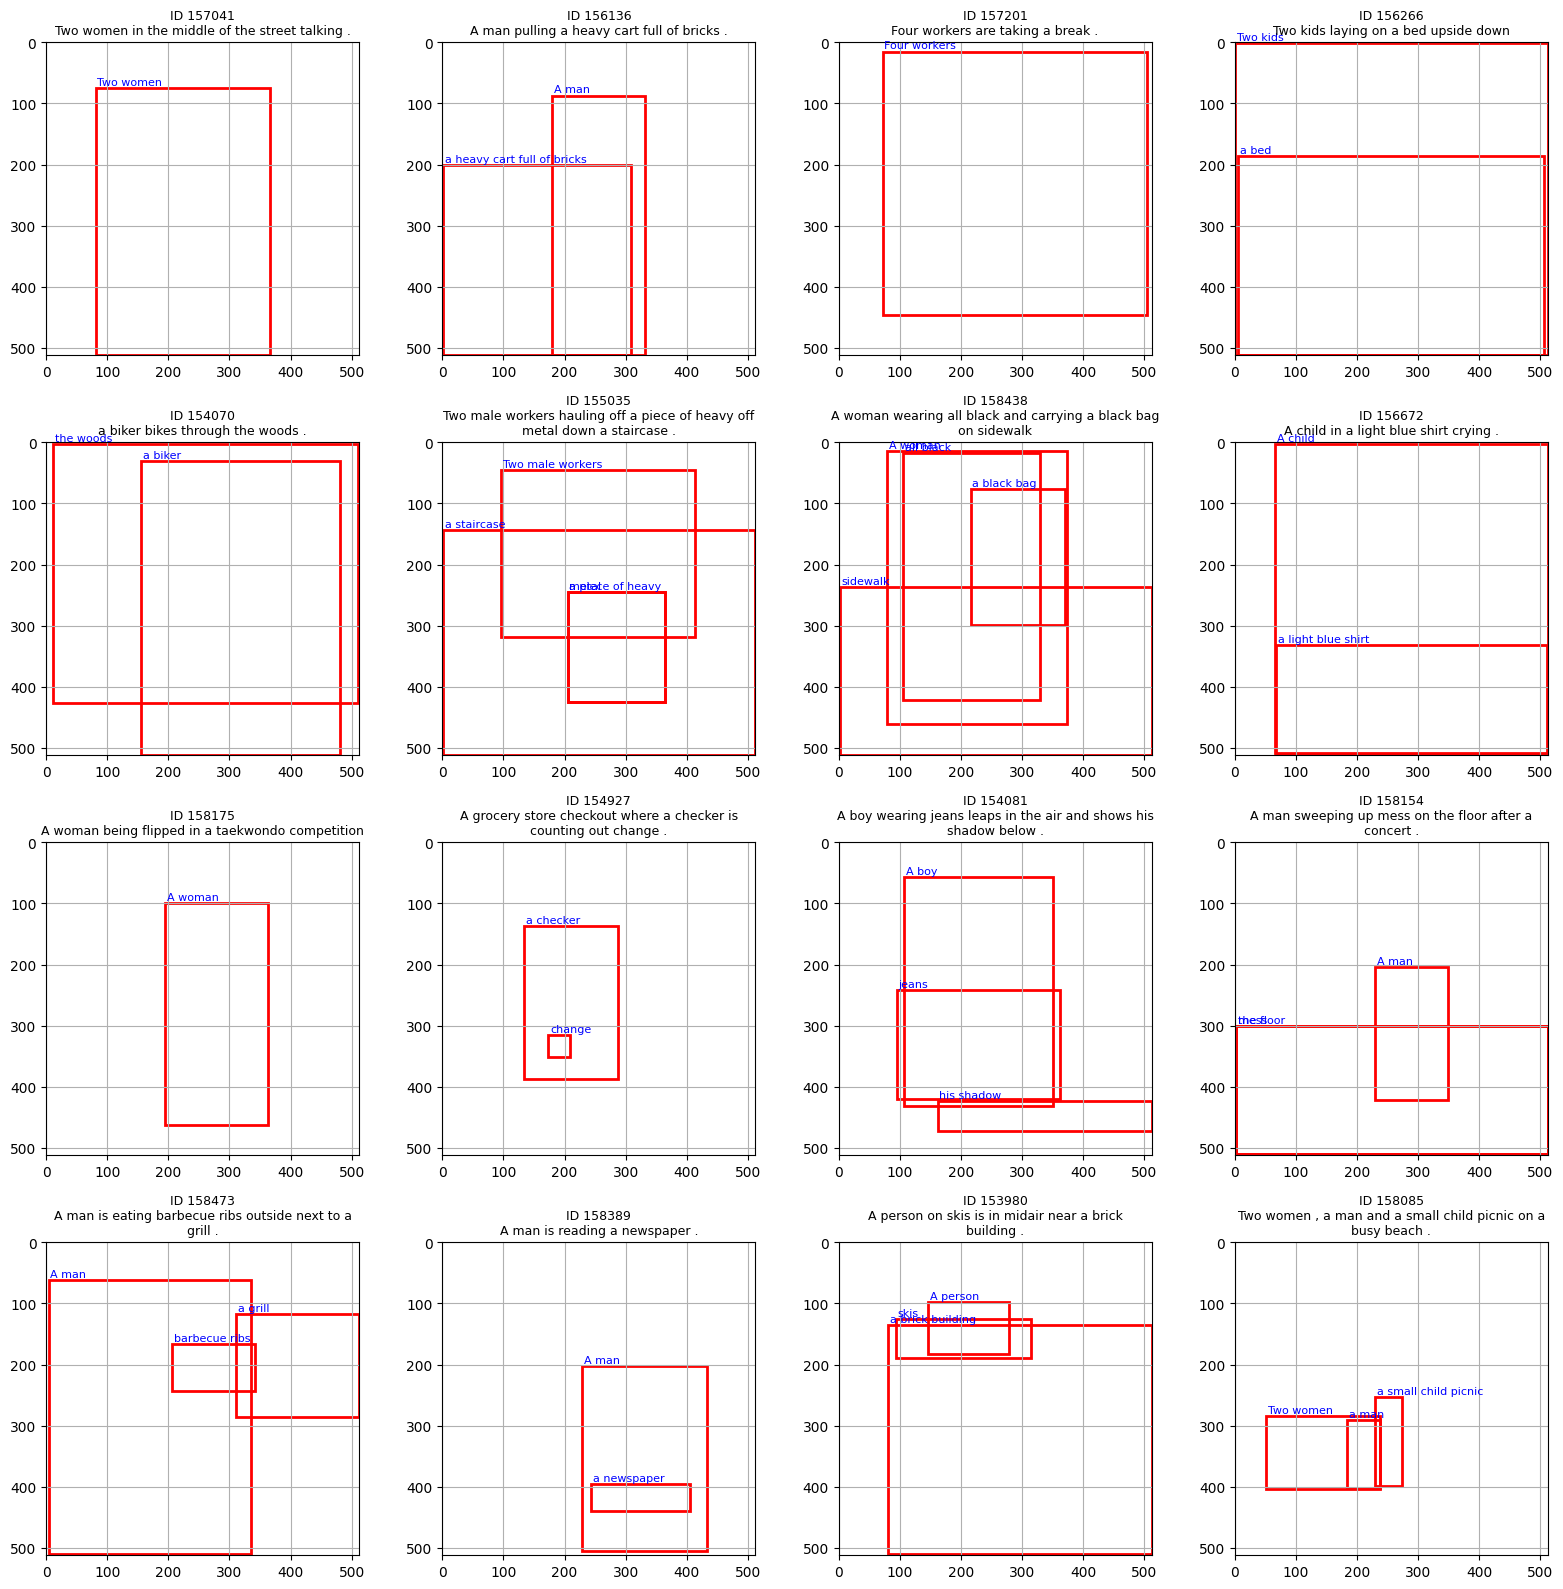

In [ ]:
visualize_df_boxes_grid(df_images, num_samples=16, boxes_per_row=4)

In [12]:
# Filter the DataFrame to get rows with exactly 8 objects
df_8_objects = df_images[df_images['boxes'].map(len) == 8]

# Iterate through the filtered DataFrame and print the full caption for each row
for index, row in df_8_objects.iterrows():
    print(f"ID: {row['id']}")
    print(f"Caption: {row['caption']}")
    print(f"Boxes: {row['boxes']}")
    print("-" * 50) # Print a separator line for clarity

ID: 153971
Caption: A man wearing a white cap is drinking water with lemon at a table next to a mirror that shows a server and three more seated customers .
Boxes: [{'obj': 'a server', 'bbox': [353, 120, 457, 421]}, {'obj': 'lemon', 'bbox': [132, 255, 160, 288]}, {'obj': 'a mirror', 'bbox': [176, 4, 510, 512]}, {'obj': 'A man', 'bbox': [1, 61, 400, 512]}, {'obj': 'a white cap', 'bbox': [1, 58, 141, 178]}, {'obj': 'a table', 'bbox': [17, 472, 273, 510]}, {'obj': 'water', 'bbox': [111, 237, 188, 342]}, {'obj': 'three more seated customers', 'bbox': [260, 223, 327, 290]}]
--------------------------------------------------
ID: 154338
Caption: In the foreground , a man in a striped shirt drinks something from a bottle while behind him stand two women with dark hair and black shirts in front of a crowd in an urban setting .
Boxes: [{'obj': 'something', 'bbox': [430, 158, 512, 253]}, {'obj': 'dark hair', 'bbox': [133, 177, 284, 351]}, {'obj': 'two women', 'bbox': [129, 180, 311, 512]}, {'obj'

# Task
Sample the dataframe `df_images` to approximately 3000 rows, maintaining the original distribution of the 'objects_num' column. Display the head of the sampled dataframe and the total number of rows.

## Calculate original distribution

### Subtask:
Determine the current distribution of 'objects_num' in `df_images`.


**Reasoning**:
The subtask is to determine the current distribution of 'objects_num' in `df_images`. This can be achieved by calculating the value counts of the 'objects_num' column and storing it in `original_distribution`.



In [13]:
original_distribution = df_images['objects_num'].value_counts().sort_index()
print("Original distribution of 'objects_num':")
print(original_distribution)

Original distribution of 'objects_num':
objects_num
1     490
2    1585
3    1579
4     838
5     281
6     117
7      41
8      25
Name: count, dtype: int64


## Determine target counts

### Subtask:
Calculate the number of rows to sample for each 'objects_num' category to achieve a total of approximately 3000 rows while maintaining the original proportions.


**Reasoning**:
Calculate the target number of rows for each `objects_num` category based on the original distribution to achieve a total of approximately 3000 rows.



In [14]:
# Calculate the total number of rows in the original distribution
total_original_rows = original_distribution.sum()

# Define the target number of rows
target_total_rows = 3300

# Calculate the sampling factor
sampling_factor = (target_total_rows / total_original_rows).round(2)

# Calculate the target counts for each category, ensuring they are integers
target_counts = (original_distribution * sampling_factor).round().astype(int)

print("Target number of rows per 'objects_num' category for sampling:")
print(target_counts)

Target number of rows per 'objects_num' category for sampling:
objects_num
1     328
2    1062
3    1058
4     561
5     188
6      78
7      27
8      17
Name: count, dtype: int64


## Sample based on target counts

### Subtask:
Sample the `df_images` DataFrame, taking the calculated number of rows for each 'objects_num' category.


**Reasoning**:
Sample the DataFrame based on the calculated target counts for each category to maintain the distribution.



In [15]:
sampled_dfs = []

for obj_num, count in target_counts.items():
    # Filter rows for the current objects_num category
    category_df = df_images[df_images['objects_num'] == obj_num]

    # Sample 'count' rows, or all available rows if 'count' is larger
    if len(category_df) >= count:
        sampled_category_df = category_df.sample(n=count, random_state=42) # Use random_state for reproducibility
    else:
        sampled_category_df = category_df # Take all rows if not enough

    sampled_dfs.append(sampled_category_df)

# Concatenate the sampled dataframes
df_images_sampled = pd.concat(sampled_dfs).reset_index(drop=True)

print("DataFrame sampled successfully, maintaining the original distribution.")
display(df_images_sampled.head())
print(f"\nTotal number of rows in the sampled DataFrame: {len(df_images_sampled)}")

DataFrame sampled successfully, maintaining the original distribution.


,file_name,height,width,id,caption,dataset_name,tokens_negative,sentence_id,original_img_id,tokens_positive_eval,positive_spans,objects_num,boxes
0,4912808658.jpg,500,333,158452,Jamaican musician entertaining passers on a si...,flickr,"[[0, 63]]",2,4912808658,"[[[0, 17]]]",[Jamaican musician],1,"[{'obj': 'Jamaican musician', 'bbox': [92, 54,..."
1,20702864.jpg,333,500,154801,Two middle-aged construction workers are jackh...,flickr,"[[0, 56]]",4,20702864,"[[[0, 36]]]",[Two middle-aged construction workers],1,[{'obj': 'Two middle-aged construction workers...
2,4893369019.jpg,375,500,158221,A crowd of people sitting on a lawn clapping .,flickr,"[[0, 46]]",4,4893369019,"[[[0, 17]]]",[A crowd of people],1,"[{'obj': 'A crowd of people', 'bbox': [40, 79,..."
3,4494075018.jpg,333,500,158614,A man standing near water lights a cigarette .,flickr,"[[0, 46]]",4,4494075018,"[[[0, 5]]]",[A man],1,"[{'obj': 'A man', 'bbox': [318, 282, 428, 512]}]"
4,6315352509.jpg,333,500,158201,this race car is going fast .,flickr,"[[0, 29]]",4,6315352509,"[[[0, 13]]]",[this race car],1,"[{'obj': 'this race car', 'bbox': [33, 169, 49..."



Total number of rows in the sampled DataFrame: 3319


## Verify sampled distribution

### Subtask:
Check the distribution of 'objects_num' in the new sampled DataFrame to confirm it closely matches the original distribution.


**Reasoning**:
Calculate and print the distribution of 'objects_num' in the sampled DataFrame and compare it to the original distribution.



In [16]:
sampled_distribution = df_images_sampled['objects_num'].value_counts().sort_index()
print("Sampled distribution of 'objects_num':")
print(sampled_distribution)

print("\nOriginal distribution of 'objects_num':")
print(original_distribution)

Sampled distribution of 'objects_num':
objects_num
1     328
2    1062
3    1058
4     561
5     188
6      78
7      27
8      17
Name: count, dtype: int64

Original distribution of 'objects_num':
objects_num
1     490
2    1585
3    1579
4     838
5     281
6     117
7      41
8      25
Name: count, dtype: int64


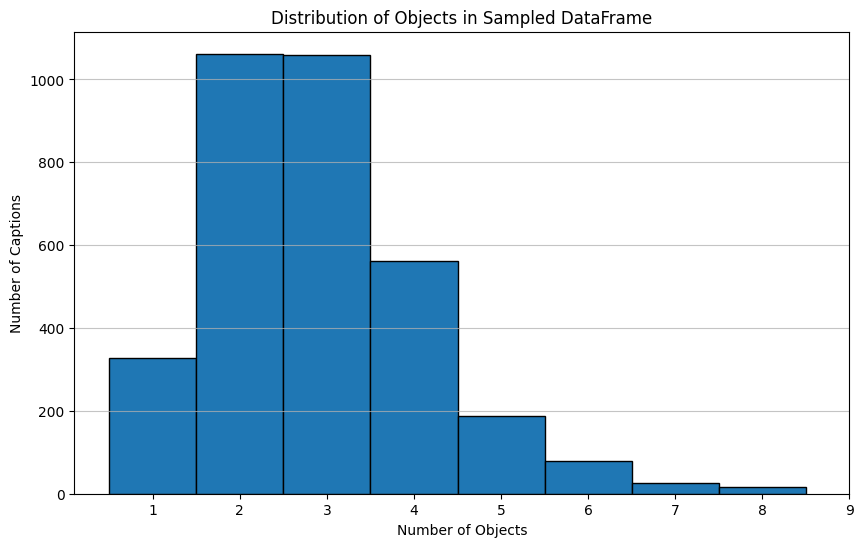

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
counts, bin_edges, patches = plt.hist(df_images_sampled['objects_num'], bins=range(1, df_images_sampled['objects_num'].max() + 2), align='left', edgecolor='black')
plt.xlabel('Number of Objects')
plt.ylabel('Number of Captions')
plt.title('Distribution of Objects in Sampled DataFrame')
plt.xticks(bin_edges) # Set xticks to be the bin edges
plt.grid(axis='y', alpha=0.75)
plt.show()

# Task
Export the sampled dataset to a CSV file named "sampled_prompts.csv" with the following columns: 'id' (0-padded to 4 digits), 'original_id', 'category' (always 'open_set'), 'prompt', and dynamically generated columns for objects and bounding boxes (e.g., 'obj1', 'bbox1', 'obj2', 'bbox2', etc.) based on the number of objects in each prompt.

## Determine maximum objects

### Subtask:
Find the maximum number of objects in the 'boxes' column of the sampled DataFrame.


**Reasoning**:
Calculate the maximum number of objects in the 'boxes' column of the sampled DataFrame and store it in a variable named `max_objects`. Then print `max_objects`.



In [ ]:
max_objects = df_images_sampled['boxes'].apply(len).max()
print(f"Maximum number of objects in the sampled DataFrame: {max_objects}")

Maximum number of objects in the sampled DataFrame: 8


## Restructure data

Create a new DataFrame with the required columns ('id', 'original_id', 'category', 'prompt') and dynamically generated columns for objects and bounding boxes (e.g., 'obj1', 'bbox1', 'obj2', 'bbox2', etc.) based on the maximum number of objects.


**Reasoning**:
Create the list of required columns and dynamically generate the object and bbox column names, then create an empty DataFrame with these columns.



In [ ]:
# Define base columns
base_columns = ['id', 'original_id', 'category', 'prompt']

# Dynamically generate object and bbox column names
object_bbox_columns = []
for i in range(1, max_objects + 1):
    object_bbox_columns.append(f'obj{i}')
    object_bbox_columns.append(f'bbox{i}')

# Combine all column names
all_columns = base_columns + object_bbox_columns

# Create an empty DataFrame with the defined columns
export_df = pd.DataFrame(columns=all_columns)

print("Empty DataFrame with required columns created successfully.")
display(export_df.head())

Empty DataFrame with required columns created successfully.


,id,original_id,category,prompt,obj1,bbox1,obj2,bbox2,obj3,bbox3,obj4,bbox4,obj5,bbox5,obj6,bbox6,obj7,bbox7,obj8,bbox8


Populate the `export_df` with data from `df_images_sampled`, ensuring correct data mapping and handling of missing object/bbox values for rows with fewer than `max_objects`.



In [ ]:
# Create an empty list to store the data for the new DataFrame
export_data = []

# Iterate over each row in the sampled DataFrame
for index, row in df_images_sampled.iterrows():
    # The 'prompt' column will now only contain the original caption
    formatted_prompt = row['caption']
    boxes = row['boxes']

    row_data = {
        'id': str(index).zfill(4),  # 0-pad index to 4 digits
        'original_id': str(row['id']),
        'category': 'open_set',      # Set category to 'open_set'
        'prompt': formatted_prompt
    }

    # Add object and bbox data to their respective columns
    for i in range(max_objects):
        if i < len(boxes):
            row_data[f'obj{i+1}'] = boxes[i]['obj']
            # Convert bbox list to a comma-separated string for bbox columns
            row_data[f'bbox{i+1}'] = ",".join(map(str, boxes[i]['bbox']))
        else:
            row_data[f'obj{i+1}'] = None # Use None for missing objects
            row_data[f'bbox{i+1}'] = None # Use None for missing bboxes


    export_data.append(row_data)

# Create the new DataFrame from the collected data
export_df = pd.DataFrame(export_data, columns=all_columns)

print("DataFrame populated with sampled data.")
display(export_df.head())

DataFrame populated with sampled data.


,id,original_id,category,prompt,obj1,bbox1,obj2,bbox2,obj3,bbox3,obj4,bbox4,obj5,bbox5,obj6,bbox6,obj7,bbox7,obj8,bbox8
0,0000,158452,open_set,Jamaican musician entertaining passers on a si...,Jamaican musician,"92,54,379,477",None,None,None,None,None,None,None,None,None,None,None,None,None,None
1,0001,154801,open_set,Two middle-aged construction workers are jackh...,Two middle-aged construction workers,"128,172,310,381",None,None,None,None,None,None,None,None,None,None,None,None,None,None
2,0002,158221,open_set,A crowd of people sitting on a lawn clapping .,A crowd of people,"40,79,478,487",None,None,None,None,None,None,None,None,None,None,None,None,None,None
3,0003,158614,open_set,A man standing near water lights a cigarette .,A man,"318,282,428,512",None,None,None,None,None,None,None,None,None,None,None,None,None,None
4,0004,158201,open_set,this race car is going fast .,this race car,"33,169,497,390",None,None,None,None,None,None,None,None,None,None,None,None,None,None


## Export to csv



In [ ]:
export_df.to_csv("sampled_prompts.csv", index=False)
print("DataFrame saved to sampled_prompts.csv successfully.")

DataFrame saved to sampled_prompts.csv successfully.
